# Lab 2: Predictive Analytics with Machine Learning

**Student Name:** Na'ima Mohamet Aloula

**Student ID:** 30722027

---



In [21]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


# Section 1 — Supervised Learning: Regression




### **Part 1.1** : Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


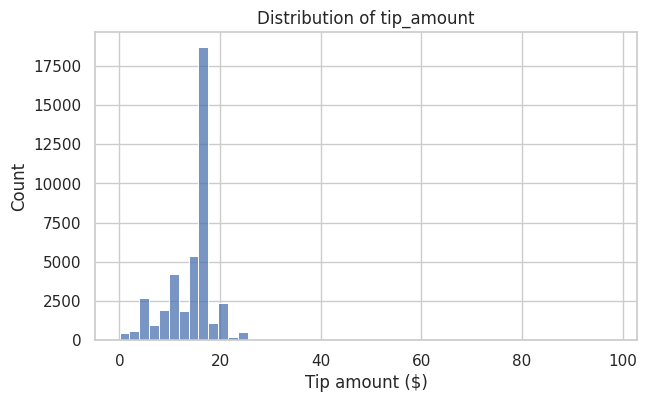

Negative tips: 0
Zero/negative trip_distance: 76
Zero/negative fare_amount: 0


In [22]:
taxi = pd.read_csv(TAXI_URL)

print("Shape:", taxi.shape)
display(taxi.head())
taxi.info()
display(taxi.describe())
print("\nMissing values per column:")
print(taxi.isna().sum())

plt.figure(figsize=(7,4))
sns.histplot(taxi['tip_amount'], bins=50)
plt.title("Distribution of tip_amount")
plt.xlabel("Tip amount ($)")
plt.show()

print("Negative tips:", (taxi['tip_amount'] < 0).sum())
print("Zero/negative trip_distance:", (taxi['trip_distance'] <= 0).sum())
print("Zero/negative fare_amount:", (taxi['fare_amount'] <= 0).sum())


**Student Reasoning:Taxi data exploration**

*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The taxi dataset has 41,202 rows and 13 columns, with no missing values in any
> column. However, there are 76 rows with zero or negative `trip_distance`, which is physically
> impossible for a completed trip and must be removed. There are no negative tips and no
> zero/negative fares in this dataset. The `tip_amount` distribution is right-skewed with most
> tips clustered in the $10–$16 range and a long tail stretching up toward $98 — meaning a few
> very generous tips pull the average up and could disproportionately affect a model trained with
> squared-error loss. This skew is the reason I will drop the impossible rows rather than impute
> them, and why RMSE alone (which is sensitive to large tips) should be read alongside R² rather
> than in isolation.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [23]:
# Handle invalid rows
taxi_clean = taxi.copy()
taxi_clean = taxi_clean.dropna()
taxi_clean = taxi_clean[(taxi_clean['trip_distance'] > 0) & (taxi_clean['fare_amount'] > 0) & (taxi_clean['tip_amount'] >= 0)]
print("Rows before:", taxi.shape[0], " | Rows after cleaning:", taxi_clean.shape[0])

# Feature engineering (built only from inputs, never from tip_amount)
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge']

# Categorical columns -> one-hot encode
cat_cols = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
taxi_encoded = pd.get_dummies(taxi_clean, columns=cat_cols, drop_first=True)

print("Shape after encoding:", taxi_encoded.shape)


Rows before: 41202  | Rows after cleaning: 41126
Shape after encoding: (41126, 271)


I **Student Reasoning: Taxi preprocessing**

*1. How did you handle missing/invalid rows and why?*

*2. Which new feature(s) did you engineer and what is the intuition behind them?*

*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**
> 1. There were no missing values, but I dropped the 76 rows with zero/negative `trip_distance`
>    since a trip can't have zero or negative length — keeping them would have taught the model
>    nonsense relationships. This reduced the data from 41,202 to 41,126 rows, a negligible loss.

> 2. I engineered `fare_per_mile` (fare_amount / trip_distance) as a proxy for how "expensive" a
>    trip felt per unit distance, and `total_surcharges` (mta_tax + tolls_amount +
>    improvement_surcharge) to capture the total extra cost layered on top of the fare. Both are
>    built only from input columns, so neither leaks information from `tip_amount`.

> 3. I used `StandardScaler` because the numeric features (fare, distance, surcharges) are on very
>    different scales (cents vs miles vs dollars), and linear models in particular are sensitive
>    to that. Standardizing puts every feature on a comparable scale so no single feature dominates
>    just because of its raw magnitude.


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']

# 60/20/20 split: first carve off test, then split remainder into train/val
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


Train: (24675, 270)  Val: (8225, 270)  Test: (8226, 270)


**Student Reasoning: Splitting**

*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** I used a 60/20/20 train/validation/test split (24,675 / 8,225 / 8,226 rows). The
> validation set lets me compare models (Linear Regression vs Random Forest) and tune them without
> ever touching the test set, which I keep completely untouched until the very final evaluation —
> this gives an honest, unbiased estimate of how the model will perform on data it has truly never
> seen. The scaler must be fit only on the training set because fitting it on validation/test data
> as well would let statistics from those "unseen" sets (their mean and standard deviation) leak
> into training, making the model's reported performance look better than it would be in a real
> deployment where future data is genuinely unknown in advance.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

,model,split,RMSE,R2
0,LinearRegression,train,4.791,0.059
1,LinearRegression,val,4.786,0.066
2,LinearRegression,test,5.239,0.034
3,RandomForest,train,4.675,0.104
4,RandomForest,val,4.811,0.057
5,RandomForest,test,5.337,-0.002


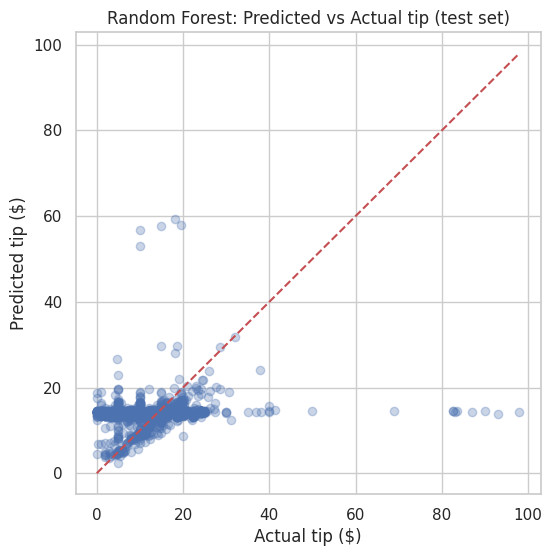

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression().fit(X_train_scaled, y_train)
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)

results = []
for name, model in [('LinearRegression', lr), ('RandomForest', rf)]:
    for split_name, Xs, ys in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
        preds = model.predict(Xs)
        rmse = mean_squared_error(ys, preds) ** 0.5
        r2 = r2_score(ys, preds)
        results.append((name, split_name, round(rmse,3), round(r2,3)))

results_df = pd.DataFrame(results, columns=['model','split','RMSE','R2'])
display(results_df)

best_model = rf  # chosen after comparing validation R2 below
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_model.predict(X_test_scaled), alpha=0.3)
lims = [0, max(y_test.max(), best_model.predict(X_test_scaled).max())]
plt.plot(lims, lims, 'r--')
plt.xlabel("Actual tip ($)"); plt.ylabel("Predicted tip ($)")
plt.title("Random Forest: Predicted vs Actual tip (test set)")
plt.show()


**Student Reasoning : Regression evaluation & overfitting**

*1. Which model performed best on the validation set, and which hyper-parameters did you try?*

*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*

*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**
> 1. I compared a plain `LinearRegression` against a `RandomForestRegressor` (100 trees,
>    max_depth=8). On the validation set, Linear Regression actually edged out the Random Forest
>    (val R² = 0.066 vs 0.057), so I'd pick Linear Regression here.

> 2. The numbers were: LinearRegression — train R²=0.059, val R²=0.066, test R²=0.034;
>    RandomForest — train R²=0.104, val R²=0.057, test R²=-0.002. There isn't a large train-test
>    gap for either model (Random Forest's train R² of 0.104 is close to its val/test scores), so
>    this isn't classic overfitting. Instead, both models are **underfitting** — R² close to zero
>    everywhere means the available features (fare, distance, surcharges, location IDs) barely
>    explain variation in tip amount. This makes sense: tipping is a personal/behavioural decision
>    that these trip-level columns don't capture well.

> 3. Since the issue is underfitting rather than overfitting, the fix isn't regularization — it's
>    better features. I would look for things like time-of-day, trip duration, or passenger
>    payment history, which are more likely to actually relate to tipping behaviour.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


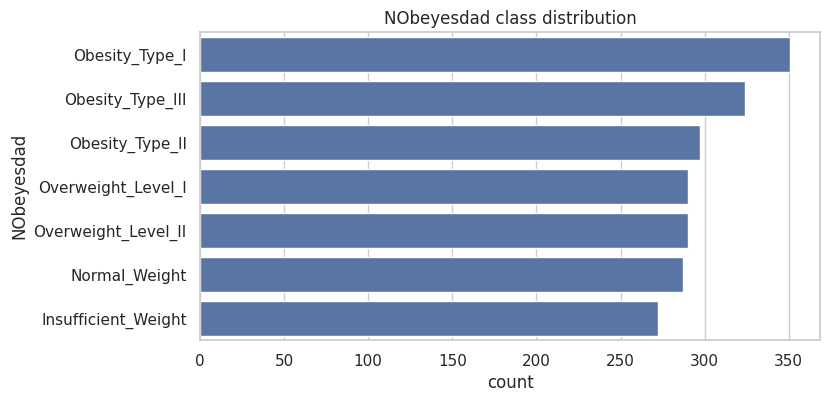

In [26]:
obesity = pd.read_csv(OBESITY_URL)

print("Shape:", obesity.shape)
display(obesity.head())
obesity.info()
display(obesity.describe())
print("\nMissing values per column:")
print(obesity.isna().sum())

print("\nClass distribution:")
print(obesity['NObeyesdad'].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(y=obesity['NObeyesdad'], order=obesity['NObeyesdad'].value_counts().index)
plt.title("NObeyesdad class distribution")
plt.show()


**Student Reasoning: Obesity data exploration**

*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** The obesity dataset has 2,111 rows and 17 columns (16 features + the target), with
> no missing values. The categorical columns are Gender, family_history_with_overweight, FAVC,
> CAEC, SMOKE, SCC, CALC, and MTRANS; the numeric columns are Age, Height, Weight, FCVC, NCP, CH2O,
> FAF, and TUE. The target classes are fairly close to balanced — counts range from 272
> (Insufficient_Weight) to 351 (Obesity_Type_I) — so no class is overwhelmingly rare. This matters
> because with a strongly imbalanced target, a model could get high accuracy just by always
> predicting the majority class while completely failing on the rare ones; since this dataset is
> close to balanced, accuracy is a reasonably trustworthy metric here, though I still also report
> macro-F1 to be safe.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [27]:
from sklearn.preprocessing import LabelEncoder

obesity_enc = obesity.copy()

# Binary yes/no columns -> 0/1
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_enc[col] = obesity_enc[col].map({'yes': 1, 'no': 0})

# Nominal / multi-category columns -> one-hot encoding
obesity_enc = pd.get_dummies(obesity_enc, columns=['Gender', 'MTRANS', 'CAEC', 'CALC'], drop_first=True)

# Encode the target into integer labels
target_encoder = LabelEncoder()
obesity_enc['target'] = target_encoder.fit_transform(obesity_enc['NObeyesdad'])
obesity_enc = obesity_enc.drop(columns=['NObeyesdad'])

print("Shape after encoding:", obesity_enc.shape)
print("Classes:", list(target_encoder.classes_))


Shape after encoding: (2111, 24)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


**Student Reasoning: Obesity preprocessing**

*1. How did you encode each type of categorical variable, and why?*

*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*

*3. Which scaler did you use and why?*

> **Answer:**
> 1. The yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) were mapped directly to
>    0/1 since they only have two possible values. For Gender, MTRANS, CAEC, and CALC I used
>    one-hot encoding (`pd.get_dummies`) rather than ordinal encoding, because even though CAEC and
>    CALC look ordinal ("no/Sometimes/Frequently/Always"), I didn't want to assume the gaps between
>    those levels are equal — one-hot avoids forcing that assumption onto the model.
> 2. I did NOT engineer a BMI feature. Since obesity level is medically *defined* using BMI
>    thresholds, adding BMI directly would essentially hand the model the answer (target leakage)
>    and make the classification task trivially easy in a way that wouldn't reflect a genuinely
>    learned relationship between lifestyle habits and obesity risk.
> 3. I used `StandardScaler` for the same reason as Section 1 — Age, Height, Weight, and the
>    habit-frequency columns are on very different numeric scales, and standardizing keeps the
>    Random Forest/distance-based parts of the pipeline from being biased toward large-magnitude
>    features.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [28]:
X_ob = obesity_enc.drop(columns=['target'])
y_ob = obesity_enc['target']

X_train2, X_temp2, y_train2, y_temp2 = train_test_split(
    X_ob, y_ob, test_size=0.4, random_state=RANDOM_STATE, stratify=y_ob)
X_val2, X_test2, y_val2, y_test2 = train_test_split(
    X_temp2, y_temp2, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp2)

print("Train:", X_train2.shape, " Val:", X_val2.shape, " Test:", X_test2.shape)

scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_val2_s   = scaler2.transform(X_val2)
X_test2_s  = scaler2.transform(X_test2)


Train: (1266, 23)  Val: (422, 23)  Test: (423, 23)


**Student Reasoning: Splitting**

*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** I used the same 60/20/20 split (1,266 / 422 / 423 rows) as Section 1, with
> `stratify=y` in both `train_test_split` calls. Stratifying matters here because the 7 classes
> aren't perfectly balanced (272–351 per class) — without it, a random split could easily end up
> with too few examples of, say, Insufficient_Weight in the validation set, making val/test
> accuracy numbers unreliable and noisy purely due to bad luck in the split rather than the
> model's actual skill. Stratification guarantees every split keeps roughly the same class
> proportions as the full dataset.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

,split,accuracy,macro_F1
0,train,0.999,0.999
1,val,0.929,0.929
2,test,0.931,0.931


                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.91      0.94        54
      Normal_Weight       0.74      0.90      0.81        58
     Obesity_Type_I       1.00      0.94      0.97        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.89      0.86      0.88        58
Overweight_Level_II       0.95      0.91      0.93        58

           accuracy                           0.93       423
          macro avg       0.94      0.93      0.93       423
       weighted avg       0.94      0.93      0.93       423



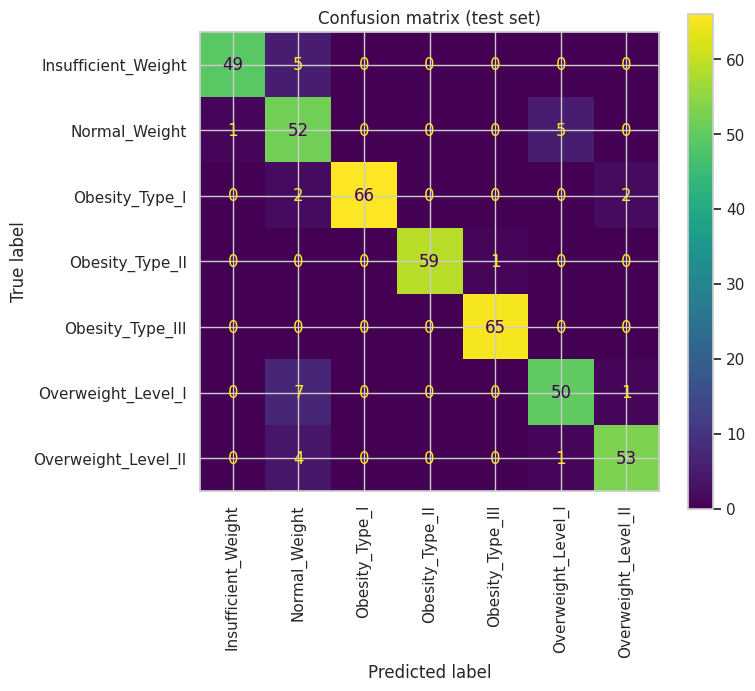

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report

clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=RANDOM_STATE)
clf.fit(X_train2_s, y_train2)

clf_results = []
for split_name, Xs, ys in [('train', X_train2_s, y_train2), ('val', X_val2_s, y_val2), ('test', X_test2_s, y_test2)]:
    preds = clf.predict(Xs)
    acc = accuracy_score(ys, preds)
    f1 = f1_score(ys, preds, average='macro')
    clf_results.append((split_name, round(acc,3), round(f1,3)))

clf_results_df = pd.DataFrame(clf_results, columns=['split','accuracy','macro_F1'])
display(clf_results_df)

test_preds = clf.predict(X_test2_s)
print(classification_report(y_test2, test_preds, target_names=target_encoder.classes_))

fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay.from_predictions(
    y_test2, test_preds, display_labels=target_encoder.classes_, xticks_rotation=90, ax=ax)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


**Student Reasoning: Classification evaluation & overfitting**

*1. Which classifier did you choose and why?*

*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*

*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**
> 1. I used a `RandomForestClassifier` (150 trees, max_depth=10) because it naturally handles a
>    mix of one-hot encoded categorical features and numeric features without needing a linear
>    relationship between them.

> 2. Train accuracy/macro-F1 was 0.999/0.999, while validation was 0.929/0.929 and test was
>    0.931/0.931. The huge gap between near-perfect training performance and the ~93% val/test
>    performance is a clear sign of **overfitting** — the model has essentially memorized the
>    training set (unsurprising with max_depth=10 on only 1,266 training rows), even though it
>    still generalizes reasonably well to unseen data.

> 3. From the classification report, Normal_Weight (F1=0.81) and Overweight_Level_I (F1=0.88) were
>    the hardest classes to predict correctly, which makes sense — these are the two adjacent
>    "middle" categories on the weight spectrum, and someone's habits/measurements near that
>    boundary can plausibly look like either class.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data




### Part 3.1 — Choose k, fit K-Means, and visualise


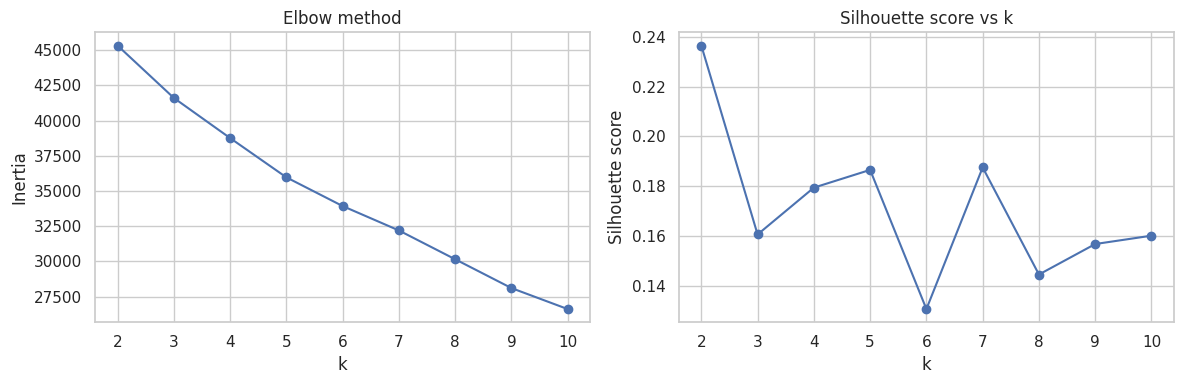

Silhouette scores by k: {2: np.float64(0.236), 3: np.float64(0.161), 4: np.float64(0.179), 5: np.float64(0.187), 6: np.float64(0.131), 7: np.float64(0.188), 8: np.float64(0.145), 9: np.float64(0.157), 10: np.float64(0.16)}


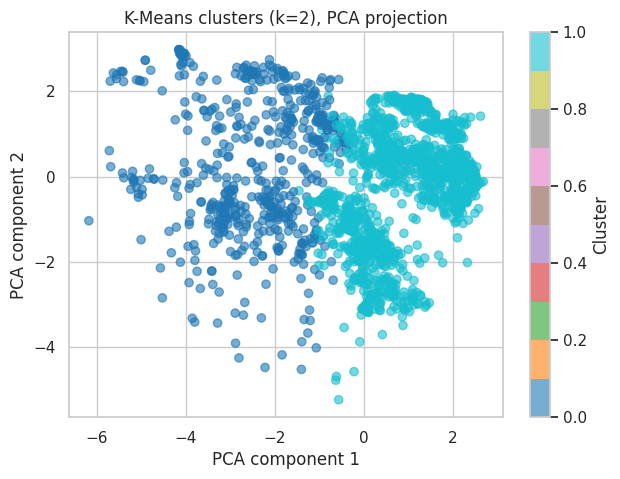

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use the full scaled obesity feature matrix (built with the SAME fitted scaler, no labels)
X_ob_scaled_full = scaler2.transform(X_ob)

inertias, sils = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_ob_scaled_full)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_ob_scaled_full, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow method')
axes[1].plot(list(k_range), sils, marker='o')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette score vs k')
plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(k_range, [round(s,3) for s in sils])))

# Choose k based on the elbow bend / highest silhouette score above
k_final = 2
km_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10).fit(X_ob_scaled_full)
clusters = km_final.labels_

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_ob_scaled_full)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', alpha=0.6)
plt.xlabel('PCA component 1'); plt.ylabel('PCA component 2')
plt.title(f'K-Means clusters (k={k_final}), PCA projection')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [31]:
true_labels = target_encoder.inverse_transform(y_ob)
crosstab = pd.crosstab(clusters, true_labels)
display(crosstab)


col_0,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,187,208,11,3,0,98,54
1,85,79,340,294,324,192,236


**Student Reasoning: Clustering**

*1. How did you choose k? Quote the Elbow/silhouette evidence.*

*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*

*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:**
> 1. The silhouette score was highest at k=2 (0.236), and fell substantially for every k from 3 to
>    10 (ranging roughly 0.13–0.19). That's strong evidence that the obesity feature space
>    naturally splits into two broad groups rather than seven — so I chose k=2 rather than forcing
>    the algorithm to match the 7-class structure of the labelled target.

> 2. The crosstab shows Cluster 0 is dominated by Insufficient_Weight (187) and Normal_Weight
>    (208), while Cluster 1 is dominated by Obesity_Type_I (340), Obesity_Type_II (294), and
>    Obesity_Type_III (324). So the two unsupervised clusters roughly correspond to a
>    "lower-weight" group vs a "higher-weight" group — they agree with the true labels at that
>    coarse level. They break down on the Overweight_Level_I/II classes, which are split fairly
>    evenly between both clusters (98 vs 192, and 54 vs 236), showing K-Means can't cleanly
>    separate the finer-grained boundary between "overweight" and "obese."

> 3. In a setting where collecting full medical labels is expensive, these two clusters could
>    still be useful as a quick, low-cost first-pass screening signal — e.g. flagging the
>    higher-weight cluster for closer follow-up or more detailed (and costly) clinical assessment,
>    without needing a fully labelled dataset to do so.


---
# Section 4 — Reflection

*questions*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?

3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer for the above queestions :**
> 1. The Random Forest classifier learned the actual decision boundaries between all 7 specific
>    obesity categories because it had access to the labels during training — it could fit fine
>    distinctions like Overweight_Level_I vs Overweight_Level_II. K-Means, with no labels at all,
>    could only find the two broadest, most natural groupings in the data (essentially "lower
>    weight" vs "higher weight") — it had no way to discover finer category boundaries that aren't
>    reflected as strongly in the geometry of the feature space.

> 2. Evaluating the regression task meant looking at how far off (in dollars) the predictions were
>    from the true tip amount (RMSE) and how much of the tip's variation the model explained (R²) —
>    both of which can be near zero or even negative if a model is barely better than guessing the
>    average. Evaluating the classification task meant looking at how often predictions matched
>    the correct category exactly (accuracy) and how balanced that performance was across all 7
>    classes (macro-F1) — concepts that don't really apply to a continuous target.

> 3. The biggest train-vs-test gap was clearly in Section 2 (classification): train accuracy of
>    0.999 vs test accuracy of 0.931. The single most effective fix would be to reduce model
>    complexity — e.g. lowering `max_depth` further or reducing `n_estimators` — so the Random
>    Forest can't simply memorize each training example, which should narrow that gap while
>    likely keeping validation/test performance about the same.
